**1. Data Loading**
* What it does: downloads the BreastMNIST dataset and transforms the raw images into pytorch tensors.
* Why it is needed: pytorch models require numerical tensors to perform mathematical operations, not raw image files.
* Expected outcome: train, validation, and test dataset objects structured as tensors.

In [9]:
from medmnist import BreastMNIST

dataset = BreastMNIST(split="train", download=True)

In [10]:
import torchvision.transforms as transforms
from medmnist import BreastMNIST

#we define the convertion of the images from the dataset to tensors
data_transform = transforms.Compose([transforms.ToTensor()])

#download and load the datasets with the tensor transformation applied
train_dataset = BreastMNIST(split="train", transform=data_transform, download=True)
val_dataset = BreastMNIST(split="val", transform=data_transform, download=True)
test_dataset = BreastMNIST(split="test", transform=data_transform, download=True)

**2. Visualization of raw data**
* What it does: extracts a sample ultrasound image from the training set and plots it.
* Why it is needed: to visually verify the 28x28 grayscale format and confirm the binary labels (0:benign, 1:malignant) match the problem.
* Expected outcome: a plot showing a grayscale image with a 0 (benign) or 1 (malignant) label.

Text(0.5, 1.0, 'Label: 1')

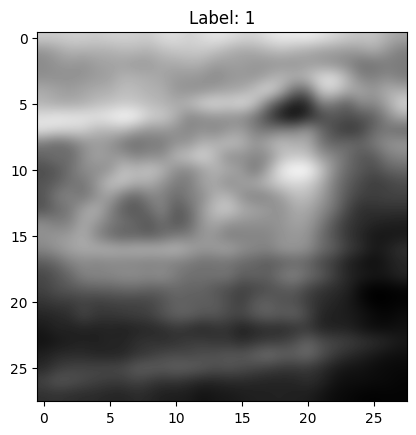

In [11]:
import matplotlib.pyplot as plt

#extract the image 67 from the training dataset
img, label = train_dataset[67]

#we apply interpolation for visualization purposes, but in fact it doesnt change how the machine processes the image
plt.imshow(img.squeeze(), cmap="gray", interpolation="bicubic")

plt.title(f"Label: {label[0]}")
#we will get a lable:0 if its a benign tumor and 1 if its a malignant

**3. Train/Test Split**
* What it does: turn the datasets into pytorch DataLoader objects.
* Why it is needed: processing the entire dataset at once consumes too much memory. DataLoaders allow us to feed the model in smaller batches (32 images).
* Expected outcome: Iterable dataloader objects for train, validation, and test sets.

In [12]:
from torch.utils.data import DataLoader
import torch

#set a seed for same results and not randomness
torch.manual_seed(8)

#define the batch size to process each epoch/k
b_size = 32

#creating the dataloaders
train_loader = DataLoader(dataset=train_dataset, batch_size=b_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=b_size, shuffle=False)

print(f"number of batches for training: {len(train_loader)}")

number of batches for training: 18


**4. Model Definition**
* What it does: Defines a Logistic Regression model as a single linear layer followed by a Sigmoid activation.
* Why it is needed: It serves as our classical ML baseline, mapping 784 flattened pixels into a single probability score (0 to 1).
* Expected outcome: An initialized PyTorch model ready for training.

In [13]:
import torch.nn as nn

class LogisticRegression(nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(28*28, 1) #(28x28 pixeles, 1 prediction output)
    def forward(self,x):
        #turn the image into flat
        x = x.view(-1, 28*28)
        output = self.linear(x)

        #apply sigmoid to get a probabilty between 0-1
        prob = torch.sigmoid(output)
        return prob
    
#our model
model = LogisticRegression()    


**5. Training Loop**
* What it does: Iterates over the training data, computes the binary cross entropy loss (BCE), and updates weights using Backpropagation.
* Why it is needed: This is the learning process where the optimizer adjusts the models parameters to minimize errors in prediction.
* Expected outcome: A trained model and a list of average loss values per epoch/k.

In [14]:
#first we define the loss function and optimizer

criterion = nn.BCELoss() #binary cross entropy loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) #Stochastic Gradiend Descent

num_k = 10
lossL = []

#Training Loop
for k in range(num_k):
    k_loss=0
    for i, (images,labels) in enumerate(train_loader):
        #convert labels to float to match the model output type
        labels = labels.float()
        
        #predictions
        outputs = model(images)

        #calculate the loss using BCE loss
        loss = criterion(outputs, labels)

        #backward pass and optimize (Backpropagation)
        optimizer.zero_grad() #clear old gradients
        loss.backward()  #compute new gradients
        optimizer.step() #update weights

        k_loss += loss.item()

    #calculate average loss for the epoch/k and save it in a list lossL
    average_loss = k_loss / len(train_loader)
    lossL.append(average_loss)
    print(f"k [{k+1}/{num_k}], Loss: {average_loss:.4f}")

k [1/10], Loss: 0.5805
k [2/10], Loss: 0.5748
k [3/10], Loss: 0.5455
k [4/10], Loss: 0.5397
k [5/10], Loss: 0.5479
k [6/10], Loss: 0.5279
k [7/10], Loss: 0.5569
k [8/10], Loss: 0.5597
k [9/10], Loss: 0.5478
k [10/10], Loss: 0.5495


**6. Evaluation Metrics**
* What it does: calculates the final accuracy on the unseen test set and plots the training loss curve.
* Why it is needed: to evaluate how well the model generalizes to new data and to visually confirm that the learning process was stable.
* Expected outcome: a test accuracy % and a graph of the training loss.

Final Test Accuracy: 75.64%


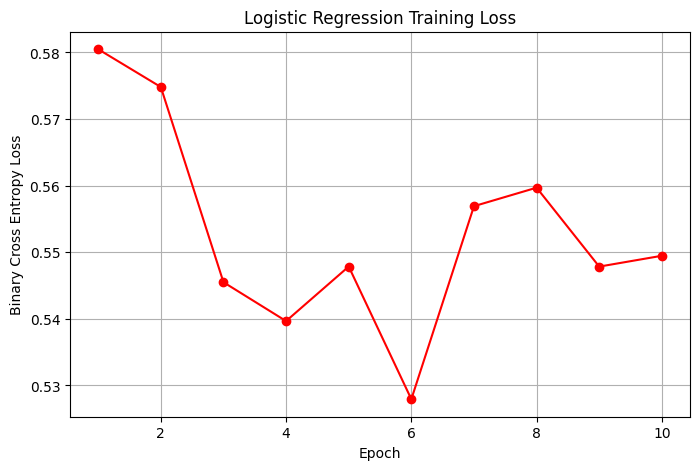

In [15]:
#evaluate the model
model.eval()
correct = 0
total = 0

#disable gradient calculation for testing
with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.float()
        outputs = model(images)
        
        #if probability > 0.5, predict 1 (malignant), else predict 0 (benign)
        predicted = (outputs >= 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Final Test Accuracy: {accuracy:.2f}%")

# Plot the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_k+ 1), lossL, marker="o", color="red")
plt.title("Logistic Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()

**7. Decision Boundary Visualization (Basic PyTorch)**
* What it does: Reduces the image data to 2 dimensions using pytorch pca_lowrank, trains a minimal 2D Logistic Regression model, and plots a basic scatter plot with the decision boundary.
* Why it is needed: Visualizing a boundary in 784 dimensions is impossible. Using PCA to project data to 2D allows us to see how the model separates the classes.
* Expected outcome: A simple 2D scatter plot with a basic colored background showing the separation between Benign and Malignant tumors.

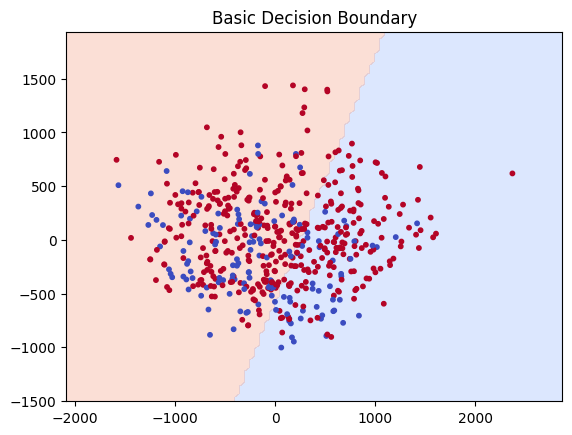

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

#prepare data
X = torch.tensor(train_dataset.imgs).view(-1, 28*28).float()

#the pca breaks the math and creates 2 variables that work as axis for the graph
X_pca = torch.matmul(X - X.mean(dim=0), torch.pca_lowrank(X - X.mean(dim=0), q=2)[2][:, :2])

y = torch.tensor(train_dataset.labels).float()

#2D pytorch model and training
model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt = torch.optim.Adam(model.parameters(), lr=0.1)
for _ in range(50):
    opt.zero_grad()
    nn.BCELoss()(model(X_pca), y).backward()
    opt.step()

#background grid
x_grid = np.linspace(X_pca[:, 0].min()-500, X_pca[:, 0].max()+500, 100)
y_grid = np.linspace(X_pca[:, 1].min()-500, X_pca[:, 1].max()+500, 100)
xx, yy = np.meshgrid(x_grid, y_grid)
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()]).float()

#predict and plot
Z = model(grid).detach().numpy().reshape(100, 100) > 0.5
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.squeeze(), cmap='coolwarm', s=10)
plt.title("Basic Decision Boundary")
plt.show()